# Long-Short (Dollar-Neutral) Momentum — monthly & weekly

Cross-sectional momentum traded **long-short**: each rebalance go **long the top
quantile** and **short the bottom quantile** by risk-adjusted 12-1 momentum, each
leg summing to ±1 → **net exposure 0, gross exposure 2×** before vol-targeting. The
book is then scaled to a **20% vol target** (gross leverage = 2 × the multiplier),
so this section is mainly about **how much leverage that takes** and whether the
short leg adds anything.

Two selection widths, both at **monthly and weekly** rebalance:
* **normal** — top/bottom **20%**
* **top-5%** — top/bottom **5%** (concentrated)

> **Caveats up front.** (1) **Stock-borrow / short-financing costs are NOT modelled**
> — real long-short net returns would be lower. (2) Long-short momentum carries the
> classic **"momentum crash"** tail risk (losers rallying violently, e.g. 2009);
> watch the drawdowns. (3) Market-neutral, so the long-only S&P benchmark is not a
> fair comparison. Outputs in `results/long_short/`.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.3f}"); pd.set_option("display.max_columns", 40)
RES = "results/long_short"
for k in ["figures", "figure_data", "metrics", "weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)

md_m = ms.DataLoader("data").load()
md_w = ms.DataLoader("data", freq="W").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
MAXLEV = 3.0            # multiplier cap -> gross capped at 2 x 3 = 6x

def ls_cfg(ppy, top_pct):
    return ms.StrategyConfig(kind="ls", top_pct=top_pct, weighting="equal", target_vol=0.20,
        max_leverage=MAXLEV,
        lookback=52 if ppy == 52 else 12, gap=4 if ppy == 52 else 1,
        vol_window=52 if ppy == 52 else None,
        vol_lookback=26 if ppy == 52 else 6, vol_halflife=17.0 if ppy == 52 else 4.0)

variants = {  # name -> (market data, periods/yr, config)
    "monthly normal":  (md_m, 12, ls_cfg(12, 0.20)),
    "monthly top-5%":  (md_m, 12, ls_cfg(12, 0.05)),
    "weekly normal":   (md_w, 52, ls_cfg(52, 0.20)),
    "weekly top-5%":   (md_w, 52, ls_cfg(52, 0.05)),
}
print("variants:", list(variants))

variants: ['monthly normal', 'monthly top-5%', 'weekly normal', 'weekly top-5%']


## 1. Construction check — long top, short bottom, net ≈ 0

A quick look at the current (latest-rebalance) book for the monthly normal variant:
positive weights are longs, negative are shorts; they net to ~0 and gross to ~2×
the vol-target multiplier.

In [2]:
results = {}
for nm, (mkt, ppy, cfg) in variants.items():
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    results[nm] = res
    ms.save_weights(res, f"{RES}/weights/{nm.replace(' ', '_').replace('%','pct')}", sectors=mkt.sectors)

cur = results["monthly normal"].current_weights()
book = pd.concat([cur.head(5).rename("weight"), cur.tail(5).rename("weight")])
print("monthly normal — top 5 longs and bottom 5 shorts (of the current book):")
display(book.to_frame().assign(side=np.where(book > 0, "LONG", "SHORT")).round(4))
print("net exposure %.3f | gross exposure %.2fx" % (cur.sum(), cur.abs().sum()))

monthly normal — top 5 longs and bottom 5 shorts (of the current book):


,weight,side
symbol,,
AAPL,0.013,LONG
GS,0.013,LONG
GOOGL,0.013,LONG
GOOG,0.013,LONG
GNRC,0.013,LONG
EFX,-0.013,SHORT
DPZ,-0.013,SHORT
DIS,-0.013,SHORT
DASH,-0.013,SHORT


net exposure 0.000 | gross exposure 2.49x


## 2. Statistics & leverage (the headline)

Full metrics for all four variants. **Gross leverage** = mean / max of |long| + |short|
(net is ~0, so it's not the usual "% invested"); **unlevered vol** is the vol of the
raw gross-2 book — the gap to 20% is what the leverage has to close.

In [3]:
rows = {}
for nm, res in results.items():
    m = ms.metrics_from_result(res)
    base = ms.compute_metrics(res.base_returns, periods_per_year=res.periods_per_year)  # unlevered gross-2 book
    rows[nm] = {
        "Sharpe": m["Sharpe"], "Sortino": m["Sortino"], "CAGR": m["CAGR"], "Ann.Vol": m["Ann.Vol"],
        "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"], "WinRate": m["WinRate"],
        "ProfitFactor": m["ProfitFactor"], "AnnTurnover": m["AnnTurnover"], "AnnTCost": m["AnnTCost"],
        "GrossLev(mean)": res.leverage.mean(), "GrossLev(max)": res.leverage.max(),
        "NetExposure": res.weights.sum(axis=1).mean(), "UnlevVol": base["Ann.Vol"],
    }
tbl = pd.DataFrame(rows)
tbl.to_csv(f"{RES}/metrics/long_short_metrics.csv")
print("Long-short momentum — monthly & weekly, normal vs top-5% (net of FX/spread/impact; borrow NOT modelled):")
display(tbl.round(3))

Long-short momentum — monthly & weekly, normal vs top-5% (net of FX/spread/impact; borrow NOT modelled):


,monthly normal,monthly top-5%,weekly normal,weekly top-5%
Sharpe,-0.015,-0.183,0.242,0.124
Sortino,-0.021,-0.210,0.298,0.159
CAGR,-0.023,-0.063,0.028,0.005
Ann.Vol,0.202,0.218,0.194,0.204
MaxDrawdown,-0.678,-0.828,-0.262,-0.288
Calmar,-0.034,-0.076,0.108,0.016
WinRate,0.478,0.500,0.394,0.388
ProfitFactor,0.988,0.856,1.108,1.054
AnnTurnover,10.379,10.681,17.902,18.608
AnnTCost,0.039,0.044,0.063,0.068


## 3. Leverage through time & growth of \$1

The dollar-neutral book runs gross leverage that rises when the long-short *spread*
is calm and falls when it is volatile (the vol-target). Growth of \$1 shows whether
the short leg earns its keep.

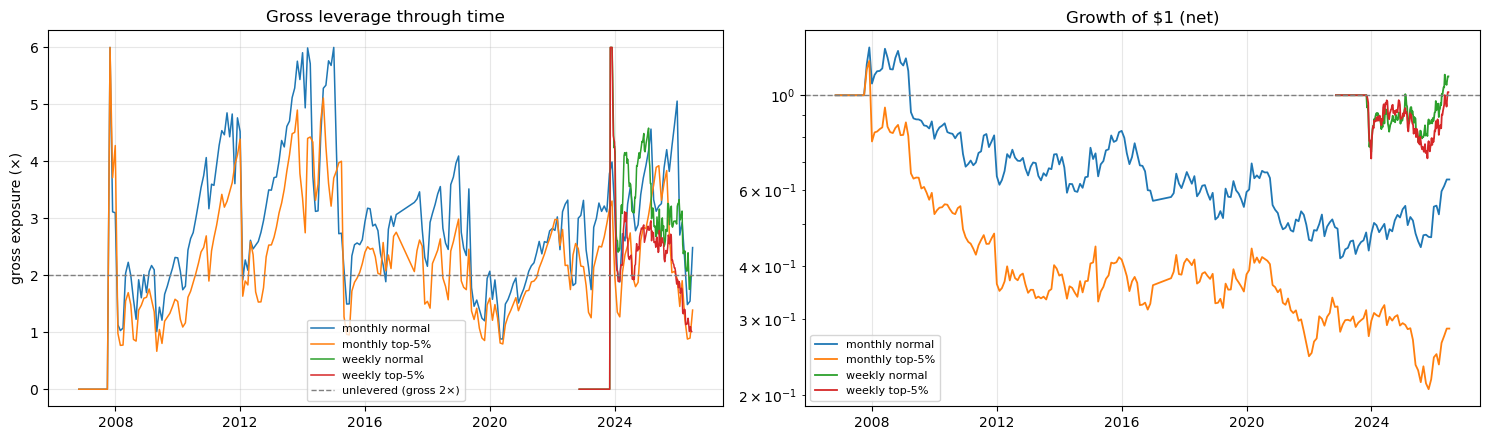

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm, res in results.items():
    ax[0].plot(res.leverage.index, res.leverage.values, label=nm, lw=1.1)
    eq = res.equity("net"); ax[1].plot(eq.index, eq.values, label=nm, lw=1.3)
ax[0].axhline(2.0, ls="--", color="grey", lw=1, label="unlevered (gross 2×)")
ax[0].set_title("Gross leverage through time"); ax[0].set_ylabel("gross exposure (×)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(1.0, ls="--", color="grey", lw=1); ax[1].set_yscale("log")
ax[1].set_title("Growth of $1 (net)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
pd.DataFrame({nm: res.leverage for nm, res in results.items()}).to_csv(f"{RES}/figure_data/leverage.csv")
pd.DataFrame({nm: res.equity("net") for nm, res in results.items()}).to_csv(f"{RES}/figure_data/growth.csv")
fig.savefig(f"{RES}/figures/leverage_and_growth.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 4. Dashboard — monthly normal

2×3 dashboard for the monthly normal book (the benchmark panel is the long-only
index, shown for reference only — this strategy is market-neutral). The drawdown
panel exposes the **2009 momentum crash**.

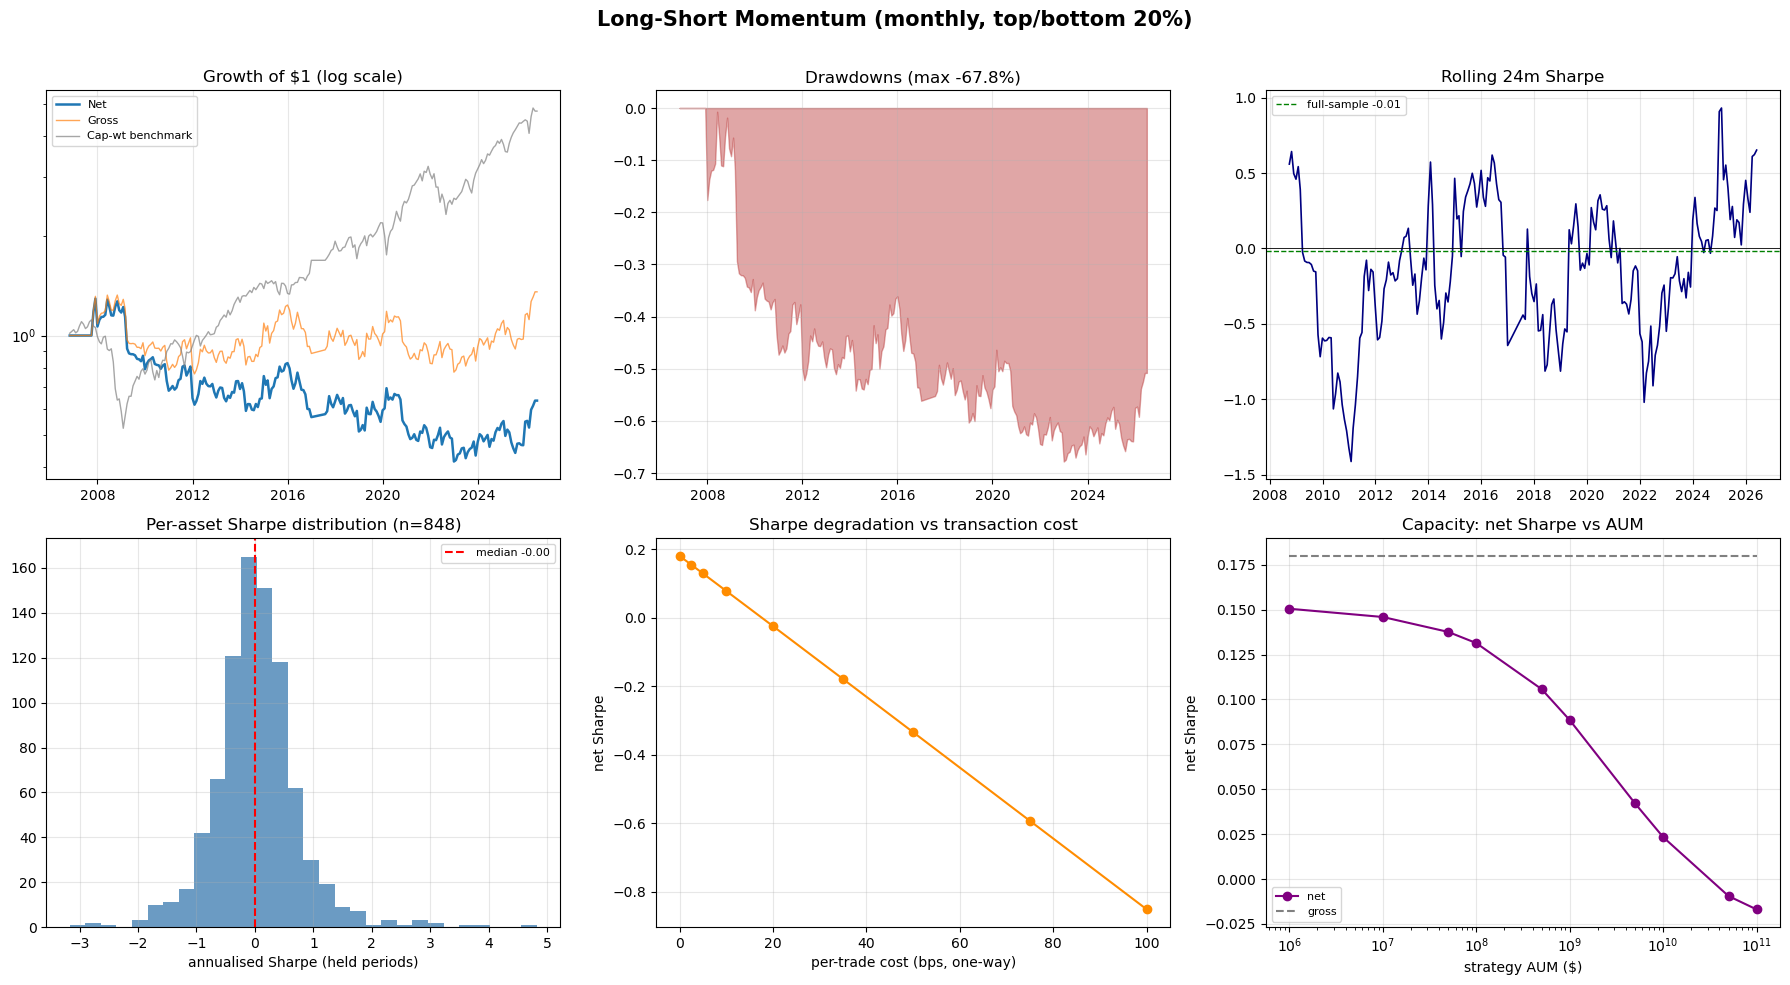

In [5]:
sig_m = ms.build_signal(md_m, variants["monthly normal"][2])
ms.plot_strategy_dashboard(results["monthly normal"], md_m, sig_m,
    "Long-Short Momentum (monthly, top/bottom 20%)",
    fig_path=f"{RES}/figures/ls_monthly_normal_dashboard.png", data_dir=f"{RES}/figure_data",
    slug="ls_monthly_normal"); plt.show()

## 5. Conclusions

* **Leverage.** Dollar-neutral (net ≈ 0). To hit 20% vol the book runs **~2–3× gross
  on average, spiking to the 6× cap** in calm-spread regimes — because the long-short
  *spread* is low-vol (unlevered ~7–12%). The **concentrated top-5% needs *less*
  leverage** (its spread is more volatile), the opposite of intuition.
* **Performance.** The short leg does **not** earn its keep in S&P large-caps:
  monthly long-short is roughly **flat-to-negative** (Sharpe ≈ 0 to −0.2) with
  **catastrophic drawdowns (−60% to −80%)** from the 2009 momentum crash. This is the
  flip side of the long-only result — the edge was *avoiding losers*, but *shorting*
  large-cap losers loses money (they rebound) and blows up in crashes. Concentration
  (top-5%) makes it worse.
* **Weekly** (short 2022-11+ sample, no 2009 crash) is mildly positive but weak
  (Sharpe ~0.1–0.2) — indicative only.
* **Bottom line.** Long-short momentum here is a **levered, crash-prone, ~zero-edge**
  book before borrow costs (which would push it further negative). The long-only /
  trend-filtered books remain the better expression of this signal.